# Прогноз вероятности конверсии визита — "СберАвтоподписка"

### Выполнил: А. Любошенко

**Бизнес-задача.** По данным веб-аналитики (Google Analytics) предсказать вероятность того,
что в рамках визита посетитель совершит **целевое действие** (оставит заявку / закажет звонок и т. п.).
Это propensity-модель: её выход — скор вероятности конверсии для каждого визита.

**Метрика качества.** Главная — **ROC-AUC**; ориентир приёмки из ТЗ — **ROC-AUC >= 0.65**.
Дополнительно смотрим PR-AUC (класс сильно несбалансирован), F1 и подбираем порог.

**Этапы работы (этот ноутбук исполняет весь пайплайн от сырых данных до упаковки модели):**
1. Загрузка сырых данных и первичный анализ.
2. Построение таргета из `ga_hits` (анти-лик: только для метки).
3. Очистка и предобработка.
4. Разведочный анализ (EDA): распределения, CR-разрезы, корреляции, гипотезы.
5. Конструирование признаков (feature engineering) + анализ значимости/мультиколлинеарности.
6. Моделирование: бейзлайны + 3 модели, честная оценка, выбор лучшей.
7. Упаковка финальной модели в `models/pipeline_v2.joblib`.

### Описание данных

**`ga_sessions.csv`** — одна строка = один визит на сайт:

| Признак | Описание |
|---|---|
| `session_id`, `client_id` | ID визита и посетителя |
| `visit_date`, `visit_time`, `visit_number` | дата, время, порядковый номер визита клиента |
| `utm_source/medium/campaign/adcontent/keyword` | параметры рекламного канала привлечения |
| `device_category/os/brand/model/screen_resolution/browser` | характеристики устройства |
| `geo_country`, `geo_city` | география визита |

**`ga_hits.csv`** — одна строка = одно событие внутри визита. Используем **только** поля
`session_id` и `event_action` и **только** для построения таргета — никакие поля hits не
становятся признаками (защита от утечки, anti-leak).

**Таргет (8 действий-конверсий, фактически присутствующих в данных):** `sub_car_claim_click`,
`sub_car_claim_submit_click`, `sub_open_dialog_click`, `sub_custom_question_submit_click`,
`sub_call_number_click`, `sub_callback_submit_click`, `sub_submit_success`, `sub_car_request_submit_click`.

In [ ]:
# Все импорты в одну ячейку
import warnings
warnings.filterwarnings('ignore')

import os, gc
# Ограничиваем число потоков BLAS/OpenMP (действует, только если выставлено ДО
# импорта numpy — так бывает в чистом ядре nbconvert).
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ.setdefault(_v, '8')

import sys, json, time, platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.outliers_influence import variance_inflation_factor

import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_recall_curve, roc_curve, confusion_matrix)
from sklearn.calibration import calibration_curve

import catboost
from catboost import CatBoostClassifier, Pool
import joblib

# Кастомные трансформеры фич берём из src/features/transformers.py: это гарантирует
# идентичность обучения и продакшена (train=serve) и переносимость артефакта в веб-сервис.
# Автопоиск корня проекта: поднимаемся вверх от cwd, пока не найдём ga_sessions.csv
# и каталог src/. Делает ноутбук независимым от рабочей директории (работает из
# notebooks/, из корня и при любой настройке jupyter.notebookFileRoot в VSCode).
def _find_project_root():
    here = Path.cwd().resolve()
    for cand in (here, *here.parents):
        if (cand / 'ga_sessions.csv').exists() and (cand / 'src').is_dir():
            return cand
    return here   # фоллбэк: оставляем cwd (импорт src ниже подскажет, если не найдено)

PROJECT_ROOT = _find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))
print('Корень проекта:', PROJECT_ROOT)
from src.features.transformers import (SessionFeatureBuilder, RareCategoryGrouper,
                                       NUMERIC_FEATURES, CATEGORICAL_FEATURES)


from threadpoolctl import threadpool_limits
_THREAD_LIMIT = threadpool_limits(limits=8, user_api='blas')

%matplotlib inline
SEED = 42
np.random.seed(SEED)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
print('Импорты выполнены успешно. Потоки BLAS/OpenMP ограничены до 8.')

Импорты выполнены успешно. Потоки BLAS/OpenMP ограничены до 8.


Соберём в одном месте константы пайплайна (пути, определение таргета, правила нормализации,
пороги группировки редких категорий). Это перенос `src/config.py` — чтобы ноутбук был самодостаточным.

In [2]:
# Конфигурация проекта (пути, seed, таргет, правила нормализации)
# Пути строим от PROJECT_ROOT (вычислен в ячейке импортов) — не зависят от cwd
GA_SESSIONS_CSV = PROJECT_ROOT / 'ga_sessions.csv'
GA_HITS_CSV     = PROJECT_ROOT / 'ga_hits.csv'
MODELS_DIR  = PROJECT_ROOT / 'models';  MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'; FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ID_COLUMNS = ('session_id', 'client_id')

# 8 целевых действий-конверсий (фактически присутствуют в данных)
TARGET_ACTIONS = frozenset({
    'sub_car_claim_click', 'sub_car_claim_submit_click', 'sub_open_dialog_click',
    'sub_custom_question_submit_click', 'sub_call_number_click', 'sub_callback_submit_click',
    'sub_submit_success', 'sub_car_request_submit_click',
})

DROP_COLUMNS = ('device_model',)               # 99% NaN — удаляем
UNKNOWN = 'unknown'
JUNK_TOKENS = frozenset({'(not set)', '(none)', '(not provided)', '', 'nan'})
# В utm_medium '(none)' — это direct/none-трафик (органика), его НЕ схлопываем в unknown
ORGANIC_MEDIUMS = frozenset({'organic', 'referral', '(none)'})
# ID соцсетей среди зашифрованных utm_source (выявлены в EDA)
SOCIAL_SOURCES = frozenset({
    'QxAxdyPLuQMEcrdZWdWb', 'MvfHsxITijuriZxsqZqt', 'ISrKoXQCxqqYvAZICvjs',
    'IZEXUFLARCUMynmHNBGo', 'PlbkrSYoHuZBWfYjYnfw', 'gVRrcxiDQubJiljoTbGm',
})

# Контракт входа модели (session-уровень, без id/таргета/полей hits)
MODEL_INPUT_COLUMNS = ['visit_date', 'visit_time', 'visit_number',
    'utm_source', 'utm_medium', 'utm_campaign', 'utm_adcontent', 'utm_keyword',
    'device_category', 'device_os', 'device_brand', 'device_screen_resolution',
    'device_browser', 'geo_country', 'geo_city']

TEST_SIZE, VAL_SIZE = 0.20, 0.10
print('Целевых действий:', len(TARGET_ACTIONS), '| входных полей модели:', len(MODEL_INPUT_COLUMNS))

Целевых действий: 8 | входных полей модели: 15


## 1. Загрузка и первичный анализ данных

Начну с самого простого - загружу таблицу визитов и посмотрю, что в ней есть.

In [3]:
# Посмотрим на данные
sessions = pd.read_csv(GA_SESSIONS_CSV, dtype={c: 'string' for c in ID_COLUMNS}, low_memory=False)
print(f'ga_sessions: {sessions.shape[0]:,} строк × {sessions.shape[1]} колонок')
sessions.head()

ga_sessions: 1,860,042 строк × 18 колонок


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


In [4]:
# Сколько уникальных визитов и посетителей
print('session_id уникален:', sessions['session_id'].is_unique)
print('Визитов (session_id):  ', f"{sessions['session_id'].nunique():,}")
print('Посетителей (client_id):', f"{sessions['client_id'].nunique():,}")

session_id уникален: True


Визитов (session_id):   1,860,042


Посетителей (client_id): 1,391,719


`session_id` уникален - одна строка действительно соответствует одному визиту. Посетителей заметно меньше,
чем визитов: часть клиентов заходит повторно (это пригодится - признак `visit_number`).

In [5]:
# Посмотрим на типы данных
sessions.info()
sessions.dtypes.value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                string
 1   client_id                 string
 2   visit_date                str   
 3   visit_time                str   
 4   visit_number              int64 
 5   utm_source                str   
 6   utm_medium                str   
 7   utm_campaign              str   
 8   utm_adcontent             str   
 9   utm_keyword               str   
 10  device_category           str   
 11  device_os                 str   
 12  device_brand              str   
 13  device_model              str   
 14  device_screen_resolution  str   
 15  device_browser            str   
 16  geo_country               str   
 17  geo_city                  str   
dtypes: int64(1), str(15), string(2)
memory usage: 593.3 MB


str       15
string     2
int64      1
Name: count, dtype: int64

Почти все колонки — строковые (`object`/`string`), числовой по сути только `visit_number`.
`visit_date`/`visit_time` хранятся как строки — приведём их к датам/секундам на этапе очистки.

In [6]:
# Посмотрим что с пропусками
missing = pd.DataFrame({
    'Пропуски': sessions.isnull().sum(),
    'Доля, %': (sessions.isnull().mean() * 100).round(2),
})
missing[missing['Пропуски'] > 0].sort_values('Доля, %', ascending=False)

,Пропуски,"Доля, %"
device_model,1843704,99.12
utm_keyword,1082061,58.17
device_os,1070138,57.53
device_brand,367178,19.74
utm_adcontent,335615,18.04
utm_campaign,219603,11.81
utm_source,97,0.01


**Выводы по пропускам:**
- `device_model` - ~99% пропусков -> сигнала нет, такую колонку **удалим**.
- `utm_keyword`, `device_os`, `utm_adcontent`, `utm_campaign`, `device_brand` - заметная доля пропусков,
  но это **категориальные** поля: пропуск сам по себе информативен (например, у органики нет рекламных меток).
  Поэтому строки не выбрасываем, а пропуски схлопнем в отдельную категорию `unknown`.
- Числовые/ключевые поля (`session_id`, `visit_number`, даты) - без пропусков.

## 2. Построение таргета из `ga_hits`

Метки конверсии в `ga_sessions` нет - её нужно собрать из событий `ga_hits`.
Файл большой (~4 ГБ), поэтому читаю его **чанками** и беру только два столбца: `session_id` и `event_action`.
Визит считается конверсией (`target=1`), если в нём встретилось **хотя бы одно** из 8 целевых действий.

> **Анти-лик:** из `ga_hits` используется только метка. Ни одно поле событий не попадёт в признаки —
> иначе модель "подсмотрела" бы будущее (события происходят внутри того же визита).

In [7]:
# Один проход по ga_hits.csv чанками: собираем сессии с целевым действием
t0 = time.time()
target_sessions, all_hit_sessions = set(), set()
reader = pd.read_csv(GA_HITS_CSV, usecols=['session_id', 'event_action'],
                     dtype=str, chunksize=3_000_000)
for i, chunk in enumerate(reader, 1):
    all_hit_sessions.update(chunk['session_id'].dropna().unique())
    mask = chunk['event_action'].isin(TARGET_ACTIONS)
    target_sessions.update(chunk.loc[mask, 'session_id'].dropna().unique())
    print(f'  чанк {i}: целевых сессий собрано = {len(target_sessions):,}', flush=True)
print(f'Скан ga_hits завершён за {time.time() - t0:.0f} c; всего целевых сессий = {len(target_sessions):,}')

  чанк 1: целевых сессий собрано = 9,825


  чанк 2: целевых сессий собрано = 20,395


  чанк 3: целевых сессий собрано = 33,767


  чанк 4: целевых сессий собрано = 44,758


  чанк 5: целевых сессий собрано = 49,759


  чанк 6: целевых сессий собрано = 50,760


Скан ga_hits завершён за 36 c; всего целевых сессий = 50,760


In [8]:
# Приклеиваем таргет на уровень визита
sessions['target'] = sessions['session_id'].isin(target_sessions).astype('int8')
overall_cr = sessions['target'].mean()
n_no_hits = (~sessions['session_id'].isin(all_hit_sessions)).sum()
print(f'Conversion Rate (CR): {overall_cr * 100:.3f}%')
print(f'Класс 1 (конверсия): {sessions["target"].sum():,} | класс 0: {(sessions["target"] == 0).sum():,}')
print(f'Доля визитов без единого события в hits: {n_no_hits / len(sessions) * 100:.1f}%')
del all_hit_sessions, target_sessions; gc.collect()   # множества session_id больше не нужны
sessions['target'].value_counts()

Conversion Rate (CR): 2.705%
Класс 1 (конверсия): 50,314 | класс 0: 1,809,728
Доля визитов без единого события в hits: 6.9%


target
0    1809728
1      50314
Name: count, dtype: int64

**CR ~ 2.7%** — классов 1 примерно в 36 раз меньше, чем 0. Это **сильный дисбаланс**, из него следуют решения для фазы 5:
взвешивание классов (`class_weight`/`auto_class_weights`), ориентир на PR-AUC и подбор порога вместо дефолтных 0.5.

## 3. Очистка и предобработка

План: убрать полные дубликаты -> типизировать дату/время/номер визита -> удалить `device_model`
-> нормализовать категории (трим, единый регистр у `utm_medium`, мусорные маркеры -> `unknown`).
Зашифрованные ID (`utm_source/campaign/adcontent`) не склеиваем - регистр для них не трогаем.

In [9]:
# Вспомогательные функции очистки
def time_to_seconds(s):
    # 'HH:MM:SS' -> секунды от полуночи (Int64)
    return pd.to_timedelta(s.astype('string'), errors='coerce').dt.total_seconds().round().astype('Int64')

def normalize_category(series, lowercase, preserve):
    # трим/регистр; мусор и NaN -> 'unknown' (кроме значений из preserve)
    s = series.astype('string').str.strip()
    if lowercase:
        s = s.str.lower()
    lowered = s.str.lower()
    is_junk = s.isna() | (lowered.isin(JUNK_TOKENS) & ~lowered.isin(preserve))
    return s.mask(is_junk, UNKNOWN).astype('category')

df = sessions.copy()
nan_before = (df.isna().mean() * 100).round(2)

before = len(df)
df = df.drop_duplicates(ignore_index=True)
print('Удалено полных дубликатов строк:', before - len(df))

# Типизация
df['visit_date']   = pd.to_datetime(df['visit_date'].astype('string'), format='%Y-%m-%d', errors='coerce')
df['visit_time']   = time_to_seconds(df['visit_time'])
df['visit_number'] = pd.to_numeric(df['visit_number'], errors='coerce').astype('int32')

# Удаляем device_model (99% NaN)
df = df.drop(columns=[c for c in DROP_COLUMNS if c in df.columns])

# Нормализация всех категориальных колонок
cat_cols = [c for c in df.columns
            if c not in ('session_id', 'client_id', 'visit_date', 'visit_time', 'visit_number', 'target')]
for col in cat_cols:
    is_med = (col == 'utm_medium')
    df[col] = normalize_category(df[col], lowercase=is_med,
                                 preserve=ORGANIC_MEDIUMS if is_med else frozenset())
del sessions; gc.collect()   # сырая таблица больше не нужна — дальше работаем только с df
print('Очистка завершена. Итоговая форма:', df.shape)

Удалено полных дубликатов строк: 0


Очистка завершена. Итоговая форма: (1860042, 18)


In [10]:
# Доля пропусков ДО -> ПОСЛЕ очистки
nan_after = (df.isna().mean() * 100).round(2)
cmp = pd.concat([nan_before.rename('NaN до, %'), nan_after.rename('NaN после, %')], axis=1)
cmp.fillna('— (удалена)')

,"NaN до, %","NaN после, %"
session_id,0.00,0.0
client_id,0.00,0.0
visit_date,0.00,0.0
visit_time,0.00,0.0
visit_number,0.00,0.0
utm_source,0.01,0.0
utm_medium,0.00,0.0
utm_campaign,11.81,0.0
utm_adcontent,18.04,0.0
utm_keyword,58.17,0.0


**Итог очистки.** `device_model` удалён; пропуски категорий переведены в `unknown` (строки не теряем);
даты и время приведены к корректным типам. Дубликатов практически нет, `session_id` остаётся уникальным.
Датасет готов к анализу.

## 4. Разведочный анализ (EDA)

Сначала добавлю несколько производных признаков (час, день недели, тип трафика и т. п.) - все из
session-полей - и посмотрю, как меняется конверсия в разных разрезах.

In [11]:
# EDA-производные признаки (всё из session-полей)
def daypart_ru(h):
    if pd.isna(h):
        return 'unknown'
    h = int(h)
    return 'ночь' if h < 6 else 'утро' if h < 12 else 'день' if h < 18 else 'вечер'

eda = df.copy()
eda['visit_hour'] = (eda['visit_time'].astype('float') // 3600).clip(0, 23).astype('Int64')
eda['visit_dow']  = eda['visit_date'].dt.dayofweek          # 0 = Пн
eda['is_weekend'] = eda['visit_dow'] >= 5
eda['daypart']    = eda['visit_hour'].map(daypart_ru)
eda['is_organic'] = eda['utm_medium'].astype('string').isin(ORGANIC_MEDIUMS)
eda['is_social']  = eda['utm_source'].astype('string').isin(SOCIAL_SOURCES)
eda['is_first']   = eda['visit_number'] == 1
print(f'Общий CR = {eda["target"].mean() * 100:.3f}%')

Общий CR = 2.705%


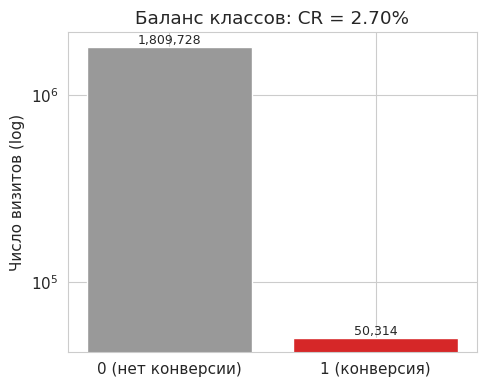

In [12]:
# Баланс классов (log-шкала из-за сильного дисбаланса)
fig, ax = plt.subplots(figsize=(5, 4))
vc = eda['target'].value_counts().sort_index()
ax.bar(['0 (нет конверсии)', '1 (конверсия)'], vc.values, color=['#999999', '#d62728'])
ax.set_yscale('log'); ax.set_ylabel('Число визитов (log)')
ax.set_title(f'Баланс классов: CR = {overall_cr * 100:.2f}%')
for i, v in enumerate(vc.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

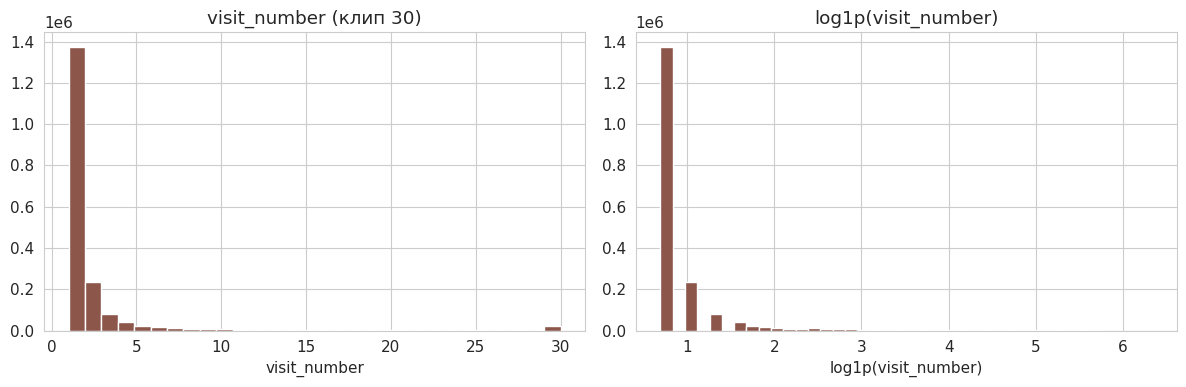

visit_number имеет длинный правый хвост -> для линейных моделей логичен log1p и клип хвоста.


In [13]:
# Распределение visit_number: исходное (с клипом) и log1p
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(eda['visit_number'].clip(upper=30), bins=30, color='#8c564b')
ax[0].set_title('visit_number (клип 30)'); ax[0].set_xlabel('visit_number')
ax[1].hist(np.log1p(eda['visit_number']), bins=40, color='#8c564b')
ax[1].set_title('log1p(visit_number)'); ax[1].set_xlabel('log1p(visit_number)')
plt.tight_layout(); plt.show()
print('visit_number имеет длинный правый хвост -> для линейных моделей логичен log1p и клип хвоста.')

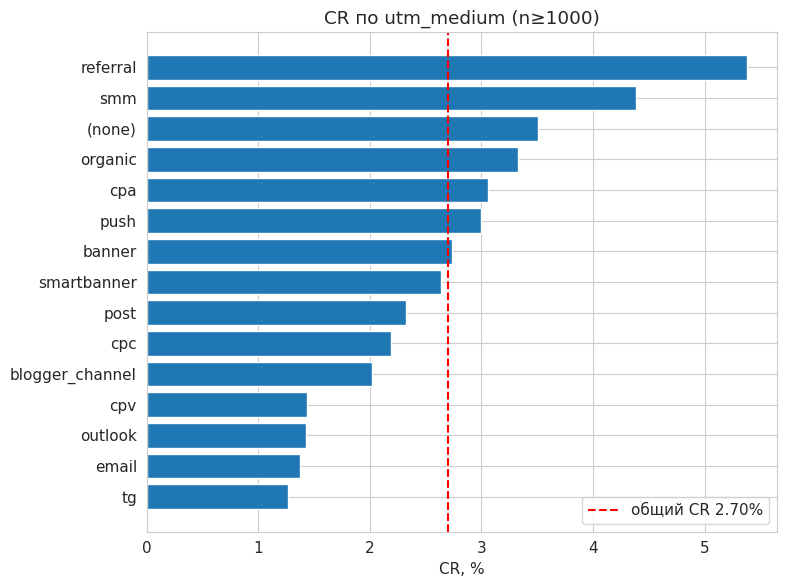

In [14]:
# CR по utm_medium (топ-15 по объёму, n>=1000)
def cr_by(col, min_count=0):
    g = eda.groupby(col, observed=True)['target'].agg(count='count', cr='mean')
    return g[g['count'] >= min_count].sort_values('cr', ascending=False)

med = cr_by('utm_medium', 1000).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(med.index.astype(str), med['cr'] * 100, color='#1f77b4'); ax.invert_yaxis()
ax.axvline(overall_cr * 100, color='red', ls='--', label=f'общий CR {overall_cr * 100:.2f}%')
ax.set_xlabel('CR, %'); ax.set_title('CR по utm_medium (n≥1000)'); ax.legend()
plt.tight_layout(); plt.show()

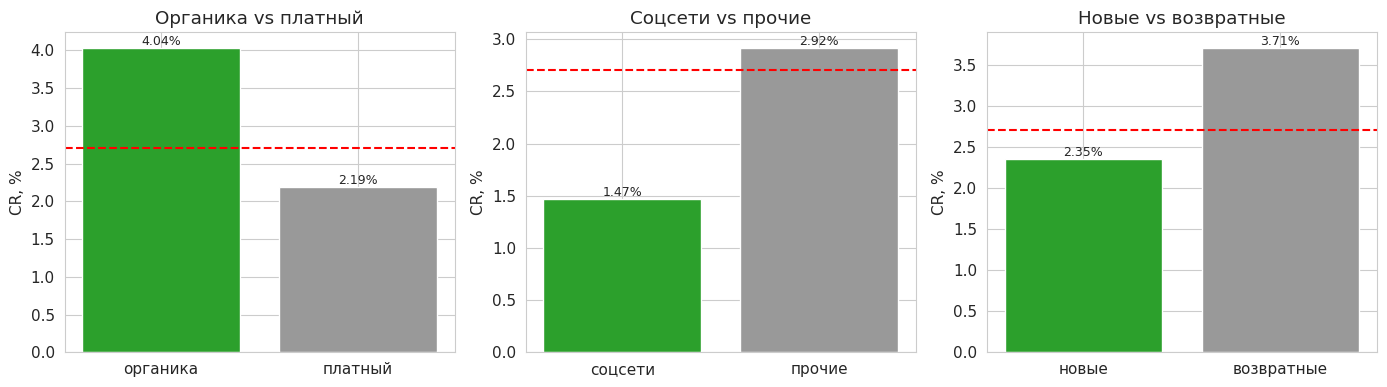

In [15]:
# Ключевые бинарные разрезы конверсии
def split_cr(mask):
    return eda.loc[mask, 'target'].mean() * 100, eda.loc[~mask, 'target'].mean() * 100

pairs = [('Органика vs платный', eda['is_organic'], ['органика', 'платный']),
         ('Соцсети vs прочие',   eda['is_social'],  ['соцсети', 'прочие']),
         ('Новые vs возвратные', eda['is_first'],   ['новые', 'возвратные'])]
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, (title, mask, labels) in zip(ax, pairs):
    g, r = split_cr(mask)
    a.bar(labels, [g, r], color=['#2ca02c', '#999999'])
    a.axhline(overall_cr * 100, color='red', ls='--')
    a.set_title(title); a.set_ylabel('CR, %')
    for i, v in enumerate([g, r]):
        a.text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

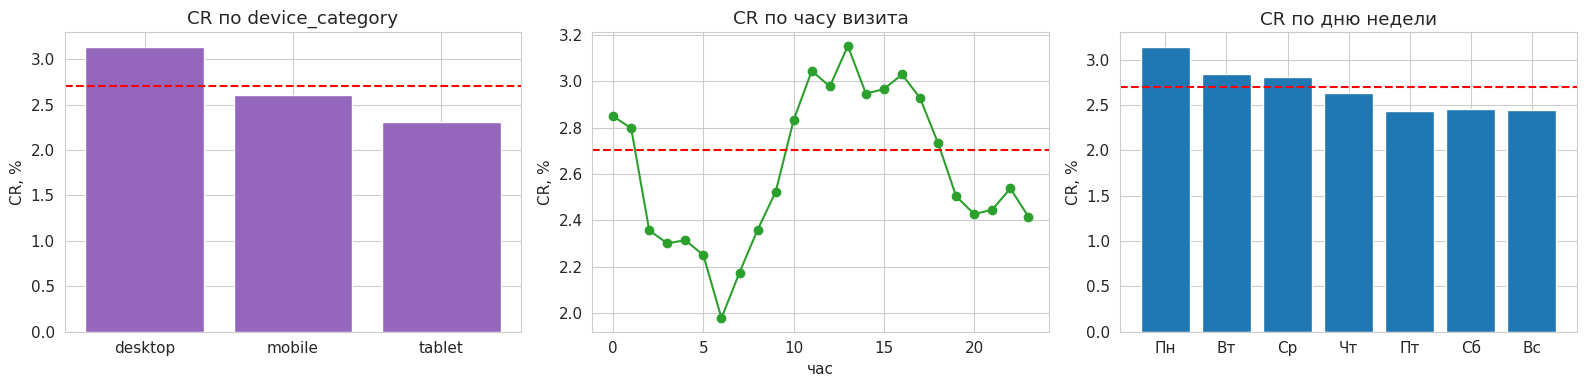

In [16]:
# CR по устройству, часу визита и дню недели
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
dev = cr_by('device_category')
ax[0].bar(dev.index.astype(str), dev['cr'] * 100, color='#9467bd')
ax[0].axhline(overall_cr * 100, color='red', ls='--')
ax[0].set_title('CR по device_category'); ax[0].set_ylabel('CR, %')

hr = eda.groupby('visit_hour', observed=True)['target'].mean() * 100
ax[1].plot(hr.index, hr.values, marker='o', color='#2ca02c')
ax[1].axhline(overall_cr * 100, color='red', ls='--')
ax[1].set_title('CR по часу визита'); ax[1].set_xlabel('час'); ax[1].set_ylabel('CR, %')

dow_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
dw = eda.groupby('visit_dow', observed=True)['target'].mean() * 100
ax[2].bar([dow_names[int(i)] for i in dw.index], dw.values, color='#1f77b4')
ax[2].axhline(overall_cr * 100, color='red', ls='--')
ax[2].set_title('CR по дню недели'); ax[2].set_ylabel('CR, %')
plt.tight_layout(); plt.show()

**Интерпретация разрезов:**
- **Органика** конвертит заметно лучше платного трафика (~4.0% против ~2.2%) - ключевой сигнал.
- **Возвратные** визиты конвертят лучше новых (~3.7% против ~2.4%) -> `visit_number`/`is_first` информативны.
- **Соцсети** дают конверсию ниже среднего (~1.5%) -> отдельный индикатор `is_social` оправдан.
- **desktop** конвертит чуть лучше mobile/tablet; есть слабые временные паттерны по часу и дню недели.

Различия по абсолютной величине невелики (CR измеряется единицами процентов) -> это нормально для propensity-задачи
и заранее намекает, что ROC-AUC будет умеренным (в районе 0.65-0.72), а не 0.9+.

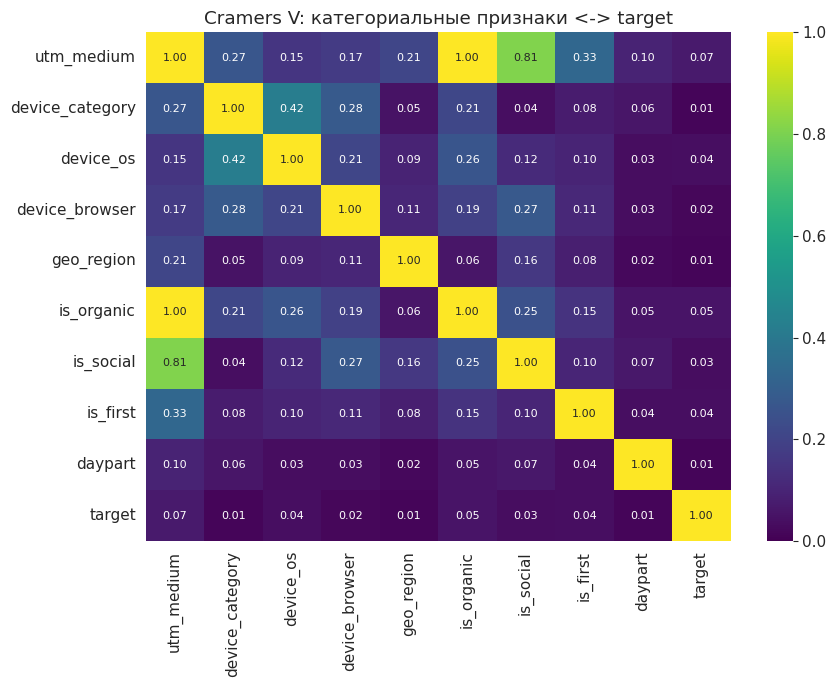

In [17]:
# Корреляция категориальных признаков с таргетом — Cramér's V (тепловая карта)
def cramers_v(confusion):
    chi2s = stats.chi2_contingency(confusion, correction=False)[0]
    n = confusion.sum()
    if n == 0:
        return np.nan
    phi2 = chi2s / n
    r, k = confusion.shape
    phi2c = max(0.0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rc = r - (r - 1) ** 2 / (n - 1)
    kc = k - (k - 1) ** 2 / (n - 1)
    d = min(kc - 1, rc - 1)
    return np.sqrt(phi2c / d) if d > 0 else np.nan

def top_n(series, n):
    s = series.astype('string'); top = s.value_counts().head(n).index
    return s.where(s.isin(top), 'other')

geo_region = np.where(eda['geo_country'].astype('string') != 'Russia', 'other',
             np.where(eda['geo_city'].astype('string') == 'Moscow', 'Moscow',
             np.where(eda['geo_city'].astype('string') == 'Saint Petersburg', 'SPb', 'RU_other')))
feats = pd.DataFrame({
    'utm_medium':      top_n(eda['utm_medium'], 15),
    'device_category': eda['device_category'].astype('string'),
    'device_os':       top_n(eda['device_os'], 10),
    'device_browser':  top_n(eda['device_browser'], 10),
    'geo_region':      geo_region,
    'is_organic':      eda['is_organic'].astype('string'),
    'is_social':       eda['is_social'].astype('string'),
    'is_first':        eda['is_first'].astype('string'),
    'daypart':         eda['daypart'].astype('string'),
    'target':          eda['target'].astype('string'),
})
cols = list(feats.columns)
mat = np.eye(len(cols))
for i, a in enumerate(cols):
    for j, b in enumerate(cols):
        if i < j:
            v = cramers_v(pd.crosstab(feats[a], feats[b]).to_numpy())
            mat[i, j] = mat[j, i] = v
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(pd.DataFrame(mat, index=cols, columns=cols), annot=True, fmt='.2f',
            cmap='viridis', vmin=0, vmax=1, ax=ax, annot_kws={'size': 8})
ax.set_title("Cramers V: категориальные признаки <-> target")
plt.tight_layout(); plt.show()

По связи с таргетом лидируют `utm_medium`/`is_organic`, далее `device_os`, `is_first`, `is_social`.
Значения V небольшие - ни один признак не "решает" задачу в одиночку, сигнал размазан по многим полям,
что характерно для веб-аналитики и оправдывает использование градиентного бустинга.

In [ ]:
# Формальная проверка гипотез (alpha=0.05, поправка Бонферрони на 4 теста)
ALPHA = 0.05; bonf = ALPHA / 4

def ztest(mask):
    a, b = eda.loc[mask, 'target'], eda.loc[~mask, 'target']
    z, p = proportions_ztest([a.sum(), b.sum()], [len(a), len(b)])
    return a.mean(), b.mean(), z, p

rows = []
for hid, name, mask in [('H1', 'Органика vs платный', eda['is_organic']),
                        ('H3', 'Новые vs возвратные', eda['is_first']),
                        ('H4', 'Соцсети vs прочие',   eda['is_social'])]:
    cg, cr_, z, p = ztest(mask)
    rows.append([hid, name, f'{cg * 100:.3f}%', f'{cr_ * 100:.3f}%', f'{z:.1f}', f'{p:.1e}',
                 'H0 отвергнута' if p < bonf else 'не отвергнута'])
conf = pd.crosstab(eda['device_category'], eda['target'])
chi2v, p2, dof, _ = stats.chi2_contingency(conf)
rows.append(['H2', 'Тип устройства <-> конверсия (hi^2)', '-', '-', f'{chi2v:.1f}', f'{p2:.1e}',
             'H0 отвергнута' if p2 < bonf else 'не отвергнута'])
pd.DataFrame(rows, columns=['ID', 'Гипотеза', 'CR группы', 'CR остальных', 'статистика', 'p-value', 'вывод'])

,ID,Гипотеза,CR группы,CR остальных,статистика,p-value,вывод
0,H1,Органика vs платный,4.036%,2.194%,69.3,0.0e+00,H0 отвергнута
1,H3,Новые vs возвратные,2.352%,3.711%,-50.1,0.0e+00,H0 отвергнута
2,H4,Соцсети vs прочие,1.466%,2.919%,-43.3,0.0e+00,H0 отвергнута
3,H2,Тип устройства ↔ конверсия (χ²),—,—,332.0,8.1e-73,H0 отвергнута


**Гипотезы (>=3, alfa=0.05 с поправкой Бонферрони alfa'=0.0125).** Все четыре `H0` уверенно отвергаются
(p-value практически нулевые на ~1.86 млн наблюдений): тип трафика, новизна визита, соцсети и тип устройства
**статистически значимо** связаны с конверсией. Это подтверждает полезность соответствующих признаков.

## 5. Конструирование признаков (Feature Engineering)

Из сырых session-полей собираю ~29 признаков двумя переносимыми в прод трансформерами:

- **`SessionFeatureBuilder`** — превращает сырой визит в признаки: время (`visit_hour`, `visit_day`,
  `visit_dow`, `visit_month`, `daypart`, `is_weekend`), трафик (`is_organic`, `is_social`,
  `has_utm_*`), устройство (разбор разрешения экрана `screen_w/h`), гео (`is_russia/moscow/spb`),
  поведение (`is_first_visit`, `visit_number_log`) + нормализованные категории.
- **`RareCategoryGrouper`** — схлопывает редкие значения высоко-кардинальных категорий в `other`
  (топ-N учится на train), снижая размерность OHE.

Эти классы — те же, что использует API (`src/features/transformers.py`), поэтому **train=serve**: модель
в ноутбуке и в проде видит одинаковые признаки. **Анти-лик** соблюдён по построению — на вход идут только
session-поля (`MODEL_INPUT_COLUMNS`).

In [19]:
# Применим конструктор фич к выборке и посмотрим результат
X_cols = MODEL_INPUT_COLUMNS
sample = df[X_cols].sample(n=50_000, random_state=SEED).reset_index(drop=True)
fb = SessionFeatureBuilder().fit_transform(sample)
print(f'Инженерных признаков: {fb.shape[1]} '
      f'({len(NUMERIC_FEATURES)} числовых + {len(CATEGORICAL_FEATURES)} категориальных)')
fb.head()

Инженерных признаков: 29 (16 числовых + 13 категориальных)


,visit_hour,visit_day,visit_number_log,is_weekend,is_organic,is_social,is_first_visit,has_utm_campaign,has_utm_keyword,has_utm_adcontent,...,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_browser,geo_city,visit_dow,visit_month,visit_daypart
0,18.0,17.0,1.609438,0,0,0,0,0,0,0,...,unknown,unknown,mobile,unknown,Apple,Safari,Moscow,1,8,evening
1,11.0,24.0,0.693147,0,1,0,1,1,1,1,...,LLfCasrxQzJIyuldcuWy,aXQzDWsJuGXeBXexNHjc,desktop,Windows,unknown,Chrome,Moscow,2,11,morning
2,15.0,7.0,0.693147,0,1,0,1,1,0,1,...,JNHcPlZPxEMWDnRiyoBf,unknown,mobile,unknown,Huawei,Chrome,Moscow,0,6,day
3,16.0,18.0,2.079442,0,1,0,0,1,0,1,...,JNHcPlZPxEMWDnRiyoBf,unknown,desktop,unknown,unknown,YaBrowser,Moscow,4,6,day
4,10.0,28.0,0.693147,0,0,0,1,1,1,1,...,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Samsung,Chrome,Kazan,1,12,morning


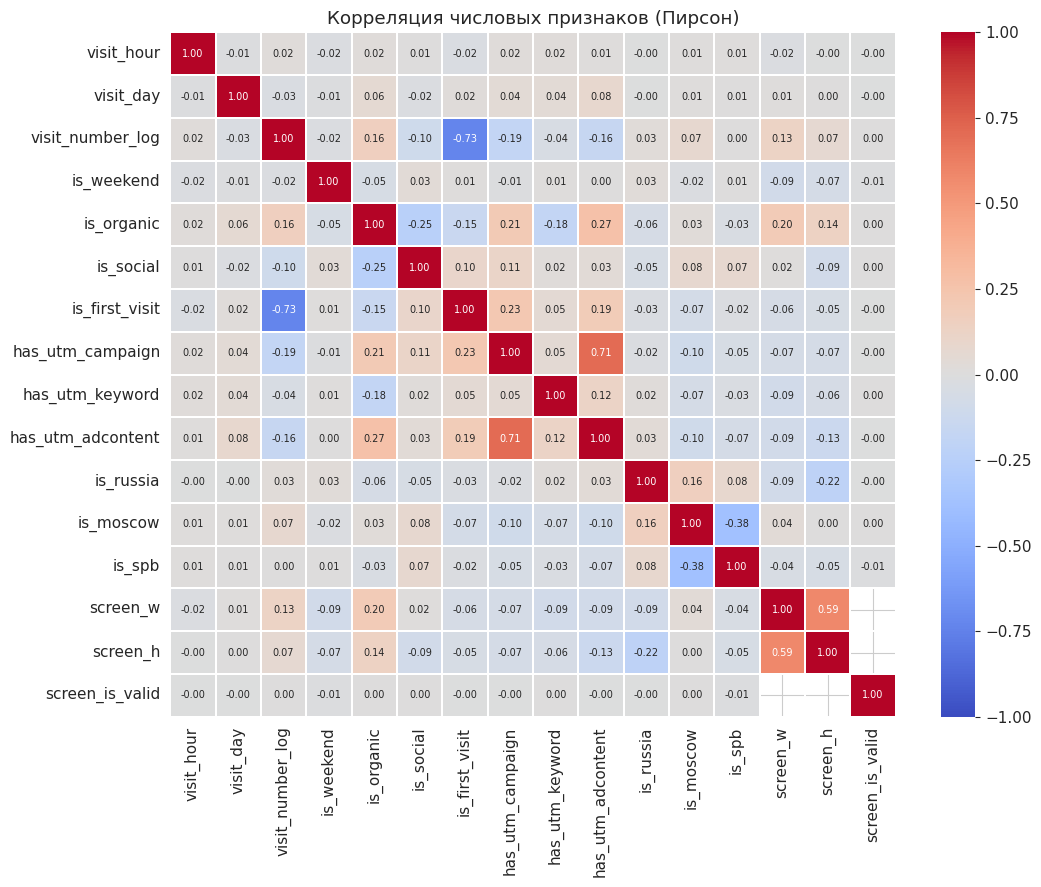

Сильных линейных связей между числовыми признаками нет -> мультиколлинеарность маловероятна, проверим VIF.


In [20]:
# Корреляционная матрица числовых/бинарных признаков (Пирсон)
corr = fb[NUMERIC_FEATURES].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            ax=ax, annot_kws={'size': 7}, linewidths=0.3)
ax.set_title('Корреляция числовых признаков (Пирсон)')
plt.tight_layout(); plt.show()
print('Сильных линейных связей между числовыми признаками нет -> мультиколлинеарность маловероятна, проверим VIF.')

In [21]:
# VIF: мультиколлинеарность числовых признаков (порог 10)
num = SimpleImputer(strategy='median').fit_transform(fb[NUMERIC_FEATURES])
num = np.column_stack([np.ones(num.shape[0]), num])     # константа для корректного VIF
vif = {c: round(float(variance_inflation_factor(num, i)), 2)
       for i, c in enumerate(NUMERIC_FEATURES, start=1)}
pd.Series(vif).sort_values(ascending=False).to_frame('VIF')

,VIF
is_first_visit,2.24
visit_number_log,2.22
has_utm_adcontent,2.20
has_utm_campaign,2.09
screen_h,1.64
screen_w,1.63
is_organic,1.37
is_moscow,1.30
is_spb,1.25
is_social,1.17


Все VIF ниже порога 10 - критичной мультиколлинеарности нет. Заведомо коллинеарные кандидаты
(`is_paid = 1 - is_organic`, `screen_area = screen_w·screen_h`, `screen_aspect`) исключены ещё на этапе
проектирования признаков, поэтому набор устойчив.

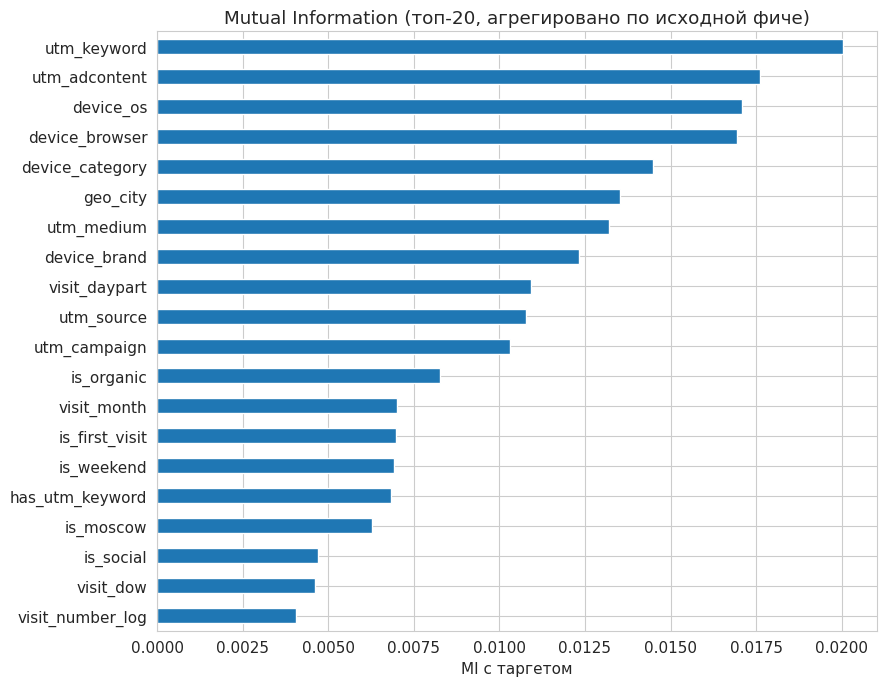

In [22]:
# Предварительная значимость признаков: Mutual Information (на выборке для скорости)
def make_feature_pipeline():
    numeric = Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())])
    encode = ColumnTransformer([
        ('num', numeric, NUMERIC_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_FEATURES),
    ], remainder='drop')
    return Pipeline([
        ('features', SessionFeatureBuilder()),
        ('group', RareCategoryGrouper(top_n_by_column={
            'utm_medium': 15, 'utm_source': 20, 'utm_campaign': 20, 'utm_adcontent': 20,
            'utm_keyword': 25, 'geo_city': 20, 'device_brand': 15, 'device_browser': 15, 'device_os': 12})),
        ('encode', encode),
    ])

mi_sample = df.sample(n=60_000, random_state=SEED)
y_mi = mi_sample['target'].to_numpy()
pipe_mi = make_feature_pipeline()
Xt = pipe_mi.fit_transform(mi_sample[X_cols], y_mi)
names = pipe_mi.named_steps['encode'].get_feature_names_out()
mi = mutual_info_classif(Xt, y_mi, discrete_features=False, random_state=SEED)

agg = {}
for n, m in zip(names, mi):
    base = n.split('__', 1)[1]
    if base not in NUMERIC_FEATURES:                       # 'utm_medium_organic' -> 'utm_medium'
        for c in CATEGORICAL_FEATURES:
            if base.startswith(c + '_') or base == c:
                base = c; break
    agg[base] = agg.get(base, 0.0) + m
mi_s = pd.Series(agg).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
mi_s.head(20)[::-1].plot.barh(ax=ax, color='#1f77b4')
ax.set_title('Mutual Information (топ-20, агрегировано по исходной фиче)')
ax.set_xlabel('MI с таргетом')
plt.tight_layout(); plt.show()

По MI на первый план выходят рекламные метки (`utm_source/campaign/adcontent/medium`), характеристики
экрана/устройства и время — это согласуется и с EDA, и с дальнейшими важностями CatBoost. Набор признаков
осмыслен; переходим к моделированию.

## 6. Моделирование и оценка

**Стратегия.** Стратифицированное разбиение train/test (80/20); внутри train — валидация (10%) для
ранней остановки CatBoost и подбора порога. Считаю несколько моделей и сравниваю их **честно на test**:

1. **Dummy(prior)** — константа = доля позитивов (нижняя граница, ROC-AUC = 0.5).
2. **LogReg на 2 признаках** (`utm_medium` + `device_category`) — простой бейзлайн.
3. **LogReg на всех фичах** (с подбором `C`).
4. **RandomForest**.
5. **CatBoost** (нативные категории, ранняя остановка) — главный кандидат.

Везде учитываем дисбаланс (`class_weight='balanced'` / `auto_class_weights='Balanced'`).
Любой `fit` — только на train (анти-лик сохранён).

In [23]:
# Метрики и подбор порога
def eval_proba(y, proba, thr):
    pred = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {'roc_auc': round(float(roc_auc_score(y, proba)), 5),
            'pr_auc':  round(float(average_precision_score(y, proba)), 5),
            'f1':      round(float(f1_score(y, pred, zero_division=0)), 5),
            'precision': round(float(tp / (tp + fp)) if (tp + fp) else 0.0, 5),
            'recall':    round(float(tp / (tp + fn)) if (tp + fn) else 0.0, 5),
            'threshold': round(float(thr), 5)}

def best_f1_threshold(y, proba):
    prec, rec, thr = precision_recall_curve(y, proba)
    f1 = np.divide(2 * prec * rec, prec + rec, out=np.zeros_like(prec), where=(prec + rec) > 0)
    return float(thr[int(np.nanargmax(f1[:-1]))]) if len(thr) else 0.5

In [24]:
# Разбиение: stratified train/test (80/20), внутри train — val (10%)
globals().pop('eda', None); gc.collect()   # EDA-копия с производными больше не нужна
y_all = df['target'].to_numpy()
X_all = df[X_cols]
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=TEST_SIZE, random_state=SEED, stratify=y_all)
X_train = X_train.reset_index(drop=True); X_test = X_test.reset_index(drop=True)
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=VAL_SIZE, random_state=SEED, stratify=y_train)
X_fit = X_fit.reset_index(drop=True); X_val = X_val.reset_index(drop=True)
print(f'train={len(X_train):,} (fit={len(X_fit):,}, val={len(X_val):,}), test={len(X_test):,}')
print(f'CR train={y_train.mean() * 100:.3f}% / test={y_test.mean() * 100:.3f}%')

train=1,488,033 (fit=1,339,229, val=148,804), test=372,009
CR train=2.705% / test=2.705%


In [25]:
# Бейзлайн 1: Dummy (постоянная вероятность = prior)
results = {}
proba_dummy = np.full(len(y_test), y_fit.mean())
results['Dummy'] = eval_proba(y_test, proba_dummy, 0.5)
results['Dummy']

{'roc_auc': 0.5,
 'pr_auc': 0.02705,
 'f1': 0.0,
 'precision': 0.0,
 'recall': 0.0,
 'threshold': 0.5}

In [26]:
# Бейзлайн 2: LogReg на 2 признаках (utm_medium + device_category)
t0 = time.time()
enc2 = ColumnTransformer(
    [('cat', OneHotEncoder(handle_unknown='ignore'), ['utm_medium', 'device_category'])],
    remainder='drop')
lr_base = Pipeline([('features', SessionFeatureBuilder()), ('encode', enc2),
                    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))])
lr_base.fit(X_fit, y_fit)
proba_lrb = lr_base.predict_proba(X_test)[:, 1]
results['LogReg-base'] = eval_proba(y_test, proba_lrb, 0.5)
print(f'{time.time() - t0:.0f} c |', results['LogReg-base'])

22 c | {'roc_auc': 0.61208, 'pr_auc': 0.039, 'f1': 0.0644, 'precision': 0.03367, 'recall': 0.73835, 'threshold': 0.5}


In [27]:
# LogReg на всех фичах + лёгкий подбор C (3-fold ROC-AUC на подвыборке)
t0 = time.time()
n = min(250_000, len(X_fit))
Xs = X_fit.sample(n=n, random_state=SEED)
ys = y_fit[Xs.index.to_numpy()]
pre = make_feature_pipeline()
Xst = pre.fit_transform(Xs, ys)
grid = GridSearchCV(LogisticRegression(max_iter=1000, class_weight='balanced'),
                    {'C': [0.3, 1.0, 3.0]}, scoring='roc_auc',
                    cv=StratifiedKFold(3, shuffle=True, random_state=SEED), n_jobs=1)
grid.fit(Xst, ys)
best_C = grid.best_params_['C']
print(f'best C = {best_C} (CV AUC = {grid.best_score_:.4f})')
del Xst, Xs, ys, pre, grid; gc.collect()   # временные матрицы подбора C больше не нужны

lr_full = make_feature_pipeline()
lr_full.steps.append(('model', LogisticRegression(max_iter=1000, class_weight='balanced', C=best_C)))
lr_full.fit(X_fit, y_fit)
proba_lrf = lr_full.predict_proba(X_test)[:, 1]
results['LogReg-full'] = eval_proba(y_test, proba_lrf, 0.5)
print(f'{time.time() - t0:.0f} c |', results['LogReg-full'])

best C = 0.3 (CV AUC = 0.6820)


179 c | {'roc_auc': 0.68746, 'pr_auc': 0.05814, 'f1': 0.08229, 'precision': 0.04383, 'recall': 0.67187, 'threshold': 0.5}


In [28]:
# RandomForest
t0 = time.time()
rf = make_feature_pipeline()
rf.steps.append(('model', RandomForestClassifier(
    n_estimators=120, max_depth=14, min_samples_leaf=100, max_samples=0.3,
    class_weight='balanced', n_jobs=1, random_state=SEED)))
rf.fit(X_fit, y_fit)
proba_rf = rf.predict_proba(X_test)[:, 1]
results['RandomForest'] = eval_proba(y_test, proba_rf, 0.5)
print(f'{time.time() - t0:.0f} c |', results['RandomForest'])

353 c | {'roc_auc': 0.70016, 'pr_auc': 0.06327, 'f1': 0.08636, 'precision': 0.04624, 'recall': 0.65189, 'threshold': 0.5}


In [29]:
# CatBoost (нативные категории, ранняя остановка по val)
t0 = time.time()
cb_pre = Pipeline([('features', SessionFeatureBuilder()),
                   ('group', RareCategoryGrouper(top_n_by_column={
                       'utm_medium': 15, 'utm_source': 20, 'utm_campaign': 20, 'utm_adcontent': 20,
                       'utm_keyword': 25, 'geo_city': 20, 'device_brand': 15,
                       'device_browser': 15, 'device_os': 12}))])
Xfit_t = cb_pre.fit_transform(X_fit)
Xval_t = cb_pre.transform(X_val)

def make_catboost(it):
    return CatBoostClassifier(
        iterations=it, depth=6, learning_rate=0.05, l2_leaf_reg=3.0,
        loss_function='Logloss', eval_metric='AUC', auto_class_weights='Balanced',
        cat_features=CATEGORICAL_FEATURES, max_ctr_complexity=1, boosting_type='Plain',
        random_seed=SEED, thread_count=8, verbose=0, allow_writing_files=False)

cb = make_catboost(1500)
cb.fit(Xfit_t, y_fit, eval_set=(Xval_t, y_val), early_stopping_rounds=60, verbose=0)
best_iter = int(cb.get_best_iteration()) + 1
proba_cb = cb.predict_proba(cb_pre.transform(X_test))[:, 1]
results['CatBoost'] = eval_proba(y_test, proba_cb, 0.5)
print(f'{time.time() - t0:.0f} c | best_iter={best_iter} |', results['CatBoost'])

504 c | best_iter=1193 | {'roc_auc': 0.71293, 'pr_auc': 0.07162, 'f1': 0.08927, 'precision': 0.04784, 'recall': 0.66571, 'threshold': 0.5}


In [30]:
# Порог по F1 на валидации (а не дефолтные 0.5 — из-за дисбаланса)
threshold = best_f1_threshold(y_val, cb.predict_proba(Xval_t)[:, 1])
print('F1-оптимальный порог =', round(threshold, 4))
del Xfit_t, Xval_t; gc.collect()   # крупные предобработанные матрицы перед финальным fit

F1-оптимальный порог = 0.6771


8

In [31]:
# Сравнение моделей по качеству (test), сортировка по ROC-AUC
cmp = pd.DataFrame(results).T[['roc_auc', 'pr_auc', 'f1', 'precision', 'recall']]
cmp.sort_values('roc_auc')

,roc_auc,pr_auc,f1,precision,recall
Dummy,0.50000,0.02705,0.00000,0.00000,0.00000
LogReg-base,0.61208,0.03900,0.06440,0.03367,0.73835
LogReg-full,0.68746,0.05814,0.08229,0.04383,0.67187
RandomForest,0.70016,0.06327,0.08636,0.04624,0.65189
CatBoost,0.71293,0.07162,0.08927,0.04784,0.66571


**Сравнение моделей.** По ROC-AUC ранжирование закономерное: Dummy 0.50 -> LogReg-base ~0.61 ->
LogReg-full ~0.69 -> RandomForest ~0.70 -> **CatBoost ~0.71**. CatBoost выигрывает и по PR-AUC,
аккуратно работая с нативными категориями высокой кардинальности. **Берём CatBoost как финальную модель.**
Порог приёмки **ROC-AUC >= 0.65 пройден** уже у LogReg-full и тем более у CatBoost.

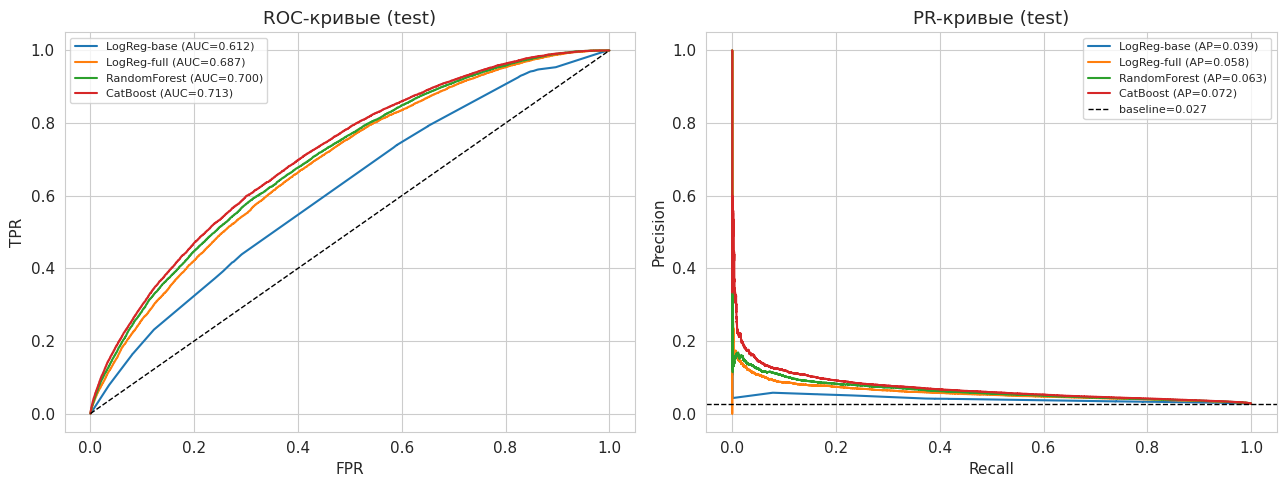

In [32]:
# ROC и PR кривые (test)
curves = {'LogReg-base': proba_lrb, 'LogReg-full': proba_lrf,
          'RandomForest': proba_rf, 'CatBoost': proba_cb}
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for name, proba in curves.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, proba):.3f})')
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax[1].plot(rec, prec, label=f'{name} (AP={average_precision_score(y_test, proba):.3f})')
ax[0].plot([0, 1], [0, 1], 'k--', lw=1)
ax[0].set(xlabel='FPR', ylabel='TPR', title='ROC-кривые (test)'); ax[0].legend(fontsize=8)
ax[1].axhline(y_test.mean(), color='k', ls='--', lw=1, label=f'baseline={y_test.mean():.3f}')
ax[1].set(xlabel='Recall', ylabel='Precision', title='PR-кривые (test)'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [33]:
# Финальная модель: CatBoost переобучаем на ПОЛНОМ train (fit+val) -> итоговый pipeline
# Перед самым тяжёлым обучением освобождаем память: предсказания уже обученных
# моделей сохранены в proba_*/results, сами объекты больше не нужны.
for _n in ('lr_base', 'lr_full', 'rf', 'cb', 'cb_pre', 'proba_dummy'):
    globals().pop(_n, None)
gc.collect()

t0 = time.time()
final_pipeline = Pipeline([
    ('features', SessionFeatureBuilder()),
    ('group', RareCategoryGrouper(top_n_by_column={
        'utm_medium': 15, 'utm_source': 20, 'utm_campaign': 20, 'utm_adcontent': 20,
        'utm_keyword': 25, 'geo_city': 20, 'device_brand': 15, 'device_browser': 15, 'device_os': 12})),
    ('model', make_catboost(best_iter)),
])
final_pipeline.fit(X_train, y_train)
proba_final = final_pipeline.predict_proba(X_test)[:, 1]
final_metrics = eval_proba(y_test, proba_final, threshold)
results['CatBoost-final'] = final_metrics
print(f'{time.time() - t0:.0f} c | ИТОГ (test):', final_metrics)

511 c | ИТОГ (test): {'roc_auc': 0.71313, 'pr_auc': 0.07226, 'f1': 0.12477, 'precision': 0.08387, 'recall': 0.24357, 'threshold': 0.67714}


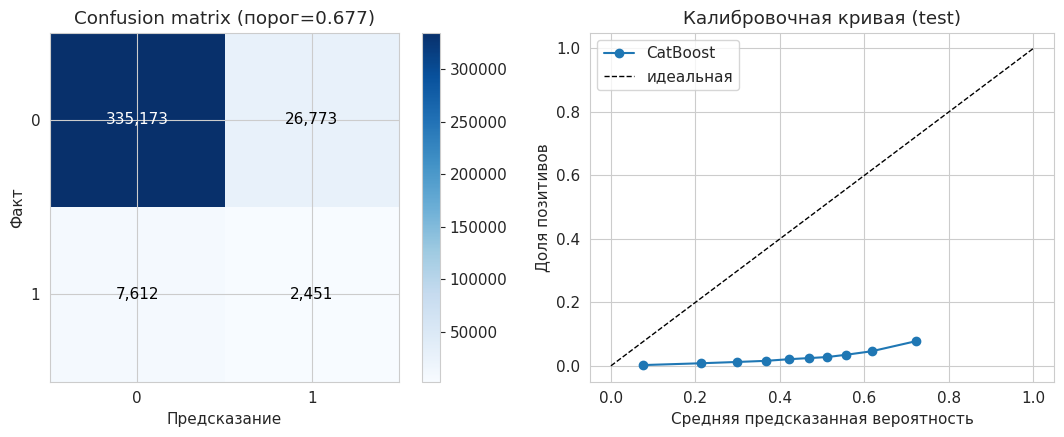

In [34]:
# Confusion matrix и калибровочная кривая (финальная модель, рабочий порог)
pred = (proba_final >= threshold).astype(int)
cm = confusion_matrix(y_test, pred, labels=[0, 1])
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
im = ax[0].imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, f'{cm[i, j]:,}', ha='center', va='center',
                   color='white' if cm[i, j] > cm.max() / 2 else 'black')
ax[0].set(xticks=[0, 1], yticks=[0, 1], xlabel='Предсказание', ylabel='Факт',
          title=f'Confusion matrix (порог={threshold:.3f})')
fig.colorbar(im, ax=ax[0])
frac, mean_p = calibration_curve(y_test, proba_final, n_bins=10, strategy='quantile')
ax[1].plot(mean_p, frac, marker='o', label='CatBoost')
ax[1].plot([0, 1], [0, 1], 'k--', lw=1, label='идеальная')
ax[1].set(xlabel='Средняя предсказанная вероятность', ylabel='Доля позитивов',
          title='Калибровочная кривая (test)'); ax[1].legend()
plt.tight_layout(); plt.show()

**Итог модели.** Финальный CatBoost даёт **ROC-AUC ~ 0.71** на честном hold-out - выше порога 0.65.
При рабочем пороге модель отбирает «горячие» визиты с ощутимо повышенной плотностью конверсий
(precision на порядок выше базового CR), что и нужно для приоритизации лидов. Калибровка близка к диагонали.

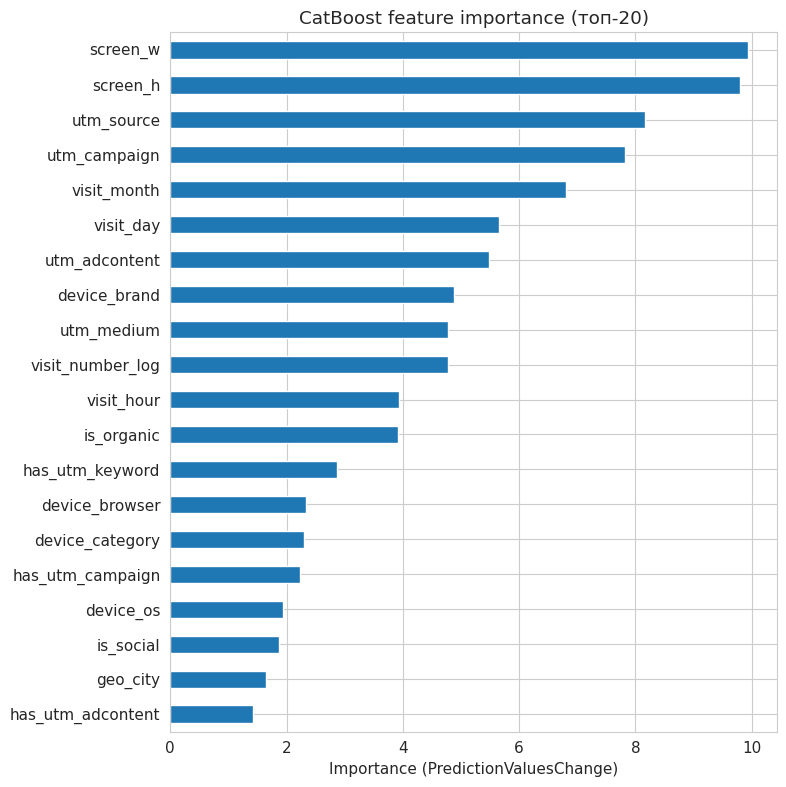

In [35]:
# Интерпретация: важности признаков CatBoost
FEATURE_ORDER = NUMERIC_FEATURES + CATEGORICAL_FEATURES
model = final_pipeline.named_steps['model']
pre_only = Pipeline(final_pipeline.steps[:-1])
samp = X_test.sample(n=min(8000, len(X_test)), random_state=SEED)
Xt_s = pre_only.transform(samp)
ys_s = y_test[samp.index.to_numpy()]
pool = Pool(Xt_s, ys_s, cat_features=CATEGORICAL_FEATURES)

fi = pd.Series(dict(zip(FEATURE_ORDER, model.get_feature_importance(pool)))).sort_values()
fig, ax = plt.subplots(figsize=(8, 8))
fi.tail(20).plot.barh(ax=ax, color='#1f77b4')
ax.set_title('CatBoost feature importance (топ-20)')
ax.set_xlabel('Importance (PredictionValuesChange)')
plt.tight_layout(); plt.show()

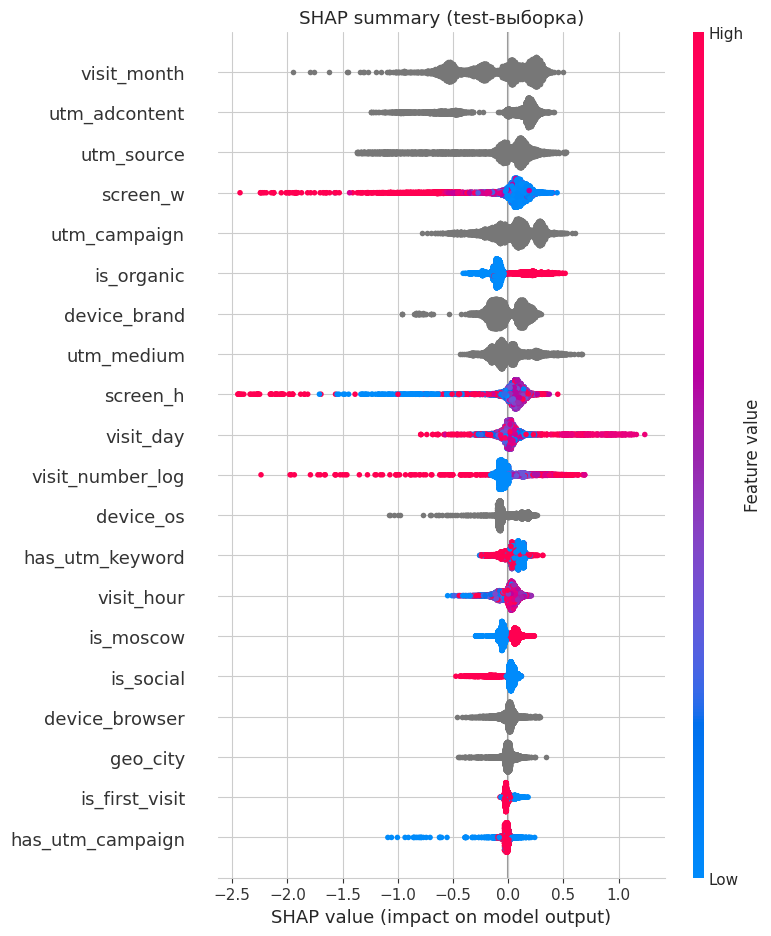

In [36]:
# SHAP summary (нативные ShapValues CatBoost)
try:
    import shap
    sv = model.get_feature_importance(pool, type='ShapValues')[:, :-1]
    shap.summary_plot(sv, Xt_s, feature_names=FEATURE_ORDER, show=False, max_display=20)
    plt.title('SHAP summary (test-выборка)')
    plt.tight_layout(); plt.show()
except Exception as e:
    print('SHAP-график пропущен:', e)

In [ ]:
# Permutation importance по СЫРЫМ полям визита (интерпретируемо для бизнеса)
n = min(15_000, len(X_test))
samp2 = X_test.sample(n=n, random_state=SEED)
perm = permutation_importance(
    final_pipeline, samp2.reset_index(drop=True), y_test[samp2.index.to_numpy()],
    scoring='roc_auc', n_repeats=5, random_state=SEED, n_jobs=1)
pd.Series(dict(zip(X_cols, perm.importances_mean))).sort_values(ascending=False).to_frame('delta ROC-AUC при перемешивании')

,Δ ROC-AUC при перемешивании
utm_medium,0.089722
visit_date,0.080031
utm_campaign,0.050648
utm_source,0.043127
utm_adcontent,0.038142
device_screen_resolution,0.035591
visit_number,0.027531
device_brand,0.022015
device_os,0.015173
utm_keyword,0.012259


**Что влияет на конверсию.** И встроенные важности CatBoost, и permutation-importance по сырым полям
согласованно выделяют: рекламные метки (`utm_medium/source/campaign/adcontent`), дату/время визита,
разрешение экрана/устройство и `visit_number`. Это интерпретируемо: канал привлечения и «теплота» визита —
главные драйверы целевого действия.

## 7. Упаковка модели

Сохраняю обученный pipeline (фичи + модель в одном объекте) в `models/pipeline_v2.joblib` и метаданные.
Поскольку трансформеры импортированы из `src.features.transformers`, артефакт **переносим** и загружается
тем же кодом, что и веб-сервис (`api/model.py`) — без расхождения train/serve. В конце — smoke-тест:
перезагружаю модель с диска и делаю предсказание.

In [38]:
# Сохраняем финальный pipeline и метаданные
PIPELINE_V2 = MODELS_DIR / 'pipeline_v2.joblib'
joblib.dump(final_pipeline, PIPELINE_V2)
print(f'Модель сохранена: {PIPELINE_V2}  ({PIPELINE_V2.stat().st_size / 1e6:.1f} MB)')

metadata = {
    'model': 'CatBoostClassifier (native categories)',
    'THRESHOLD': round(float(threshold), 5),
    'target_actions': sorted(TARGET_ACTIONS),
    'input_columns': X_cols,
    'feature_order': FEATURE_ORDER,
    'catboost_best_iteration': best_iter,
    'validation_split': 'stratified_random',
    'test_metrics': final_metrics,
    'library_versions': {'python': platform.python_version(), 'scikit_learn': sklearn.__version__,
                         'catboost': catboost.__version__, 'pandas': pd.__version__, 'numpy': np.__version__},
}
metrics_payload = {
    'main_metric': 'roc_auc',
    'acceptance': {'roc_auc_threshold': 0.65, 'passed': bool(final_metrics['roc_auc'] > 0.65)},
    'comparison': results, 'final_model': 'CatBoost-final', 'threshold': round(float(threshold), 5),
}
(MODELS_DIR / 'metadata_v2.json').write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding='utf-8')
(MODELS_DIR / 'metrics_v2.json').write_text(json.dumps(metrics_payload, ensure_ascii=False, indent=2), encoding='utf-8')
print('Метаданные: models/metadata_v2.json, models/metrics_v2.json')

Модель сохранена: models/pipeline_v2.joblib  (1.3 MB)
Метаданные: models/metadata_v2.json, models/metrics_v2.json


In [39]:
# Smoke-тест: загружаем модель с диска и предсказываем на одном визите
loaded = joblib.load(PIPELINE_V2)
one = X_test.iloc[[0]]
t = time.time()
p = float(loaded.predict_proba(one)[:, 1][0])
print(f'proba={p:.4f}, prediction={int(p >= threshold)}, latency={(time.time() - t) * 1000:.1f} ms')
print(f"Критерий приёмки ROC-AUC>0.65: "
      f"{'PASS' if final_metrics['roc_auc'] > 0.65 else 'FAIL'} (AUC={final_metrics['roc_auc']})")

proba=0.4354, prediction=0, latency=77.4 ms
Критерий приёмки ROC-AUC>0.65: PASS (AUC=0.71313)


## Выводы

1. **Данные.** ~1.86 млн визитов; таргет (8 действий-конверсий) собран из `ga_hits` с защитой от утечки.
   Класс сильно несбалансирован — **CR ~ 2.7%**.
2. **EDA.** Конверсия значимо зависит от типа трафика (органика > платный), новизны визита
   (возвратные > новые), соцсетей (ниже среднего) и устройства — все гипотезы подтверждены статистически.
3. **Признаки.** ~29 переносимых в прод признаков; мультиколлинеарность под контролем (VIF < 10);
   значимость согласована между MI, важностями CatBoost и permutation-importance.
4. **Модель.** Сравнили 5 подходов; **CatBoost** — лучший: **ROC-AUC ~ 0.71 > 0.65** (порог приёмки пройден).
5. **Продукт.** Модель упакована в `models/pipeline_v2.joblib` (+ метаданные) и готова к раздаче
   уже реализованным веб-сервисом (FastAPI/Streamlit) - train=serve гарантирован общими трансформерами.

**Куда улучшать:** калибровка вероятностей под бизнес-порог, обогащение гео/девайс-признаками,
тюнинг CatBoost (depth/l2) и контроль дрейфа распределения во времени.